# Análise de Propostas e Prestações de Contas - Governo do Estado da Paraíba 2026

O presente projeto tem como objetivo realizar uma análise aprofundada com base nas propostas de governo oficiais e nas prestações de contas registradas no Tribunal Superior Eleitoral (TSE) e no TRE-PB para o **Governo do Estado da Paraíba nas Eleições de 2026**.

Foram selecionados os planos de governo dos candidatos:
- Cícero Lucena (MDB)
- Efraim Filho (PL)
- Lucas Ribeiro (PP)

> **Estrutura de Visualização**: Cada candidato possui **células exclusivas e isoladas** para análise textual, eixos temáticos estaduais e regionais da Paraíba, temas críticos obrigatórios (*Privatização, Feminicídio, Minorias, Presídios, LGBTQIA+*), histórico partidário e prestação de contas.


In [1]:
!pip install -q pypdf pdfplumber



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import sys
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
import pypdf

try:
    import pdfplumber
except ImportError:
    pdfplumber = None

# Configurações de estilo gráfico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Download silencioso de recursos essenciais do NLTK
for res in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [3]:
def resolve_filepath(filename, subfolder=""):
    """
    Localiza o arquivo de forma inteligente em qualquer ambiente (Colab / Local).
    Busca na raiz do Colab (/content), em subpastas ou no caminho local do projeto.
    """
    possiveis_caminhos = [
        Path('/content') / filename,
        Path('/content') / 'Arquivos' / subfolder / filename,
        Path('/content') / subfolder / filename,
        Path.cwd() / filename,
        Path.cwd() / 'Arquivos' / subfolder / filename,
        Path.cwd().parent / 'Arquivos' / subfolder / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026/Arquivos') / subfolder / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026') / filename
    ]
    for p in possiveis_caminhos:
        if p.exists():
            return p
            
    for base in [Path('/content'), Path.cwd(), Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026')]:
        matches = list(base.glob(f"**/{filename}"))
        if matches:
            return matches[0]
            
    return Path(filename)


def resolve_csv(filename):
    """Localiza bases CSV na raiz do Colab (/content) ou na pasta de Dados_TSE."""
    possiveis_caminhos = [
        Path('/content') / filename,
        Path('/content') / 'Arquivos' / 'Dados_TSE' / filename,
        Path('/content') / 'Dados_TSE' / filename,
        Path.cwd() / filename,
        Path.cwd() / 'Arquivos' / 'Dados_TSE' / filename,
        Path.cwd().parent / 'Arquivos' / 'Dados_TSE' / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026/Arquivos/Dados_TSE') / filename
    ]
    for p in possiveis_caminhos:
        if p.exists():
            return p
            
    for base in [Path('/content'), Path.cwd(), Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026')]:
        matches = list(base.glob(f"**/{filename}"))
        if matches:
            return matches[0]
            
    return Path(filename)


In [4]:
def read_file_pdf(filepath):
    """Extrai texto completo de um arquivo PDF com fallback seguro."""
    filepath = Path(filepath)
    if not filepath.is_file():
        print(f"[AVISO] Arquivo não encontrado: {filepath.name}")
        return ""
    
    text = ""
    try:
        reader = pypdf.PdfReader(str(filepath))
        for page in reader.pages:
            t = page.extract_text()
            if t:
                text += t + "\n"
    except Exception:
        pass

    if not text.strip() and pdfplumber is not None:
        try:
            with pdfplumber.open(str(filepath)) as pdf:
                for page in pdf.pages:
                    t = page.extract_text()
                    if t:
                        text += t + "\n"
        except Exception:
            pass

    return text


def get_pdf_page_count(filepath):
    """Retorna o número total de páginas do arquivo PDF."""
    try:
        reader = pypdf.PdfReader(str(filepath))
        return len(reader.pages)
    except Exception:
        return 0


def extract_keywords(text, ignore_words=None, min_word_length=3):
    """Tokeniza e extrai palavras-chave filtrando stopwords e ruídos eleitorais."""
    if not text:
        return []
    
    tokens = word_tokenize(text)
    punctuations = ['(', ')', ';', ':', '[', ']', ',', '.', '--', '-', '#', '!', '*', '"', '%', '/', '\\', '?', '>', '<', '=', '+', '_', '{', '}', '@', '$', '§', '“', '”', '’']
    
    try:
        stop_words = set(stopwords.words('portuguese'))
    except Exception:
        stop_words = set()

    electoral_stopwords = {
        'governo', 'plano', 'proposta', 'propostas', 'candidato', 'candidatos',
        'programa', 'gestão', 'desenvolvimento', 'ação', 'ações', 'ano', 'anos',
        'cada', 'sobre', 'ainda', 'forma', 'todos', 'todas', 'país', 'estado',
        'município', 'nacional', 'público', 'pública', 'públicas', 'públicos',
        'social', 'sociais', 'novo', 'nova', 'novos', 'novas', 'projeto', 'projetos',
        'sistema', 'setor', 'área', 'áreas', 'população', 'pessoas', 'geral', 'bem',
        'assim', 'onde', 'além', 'através', 'fazer', 'garantir', 'promover', 'ampliar',
        'criar', 'fortalecer', 'melhorar', 'deve', 'devem', 'ser', 'ter', 'estar',
        'brasil', 'paraíba', 'brasileiro', 'brasileira', 'paraibano', 'paraibana'
    }
    
    all_stop = stop_words.union(electoral_stopwords)
    if ignore_words:
        all_stop.update([w.lower() for w in ignore_words])
    
    keywords = []
    for word in tokens:
        w_clean = word.strip()
        w_lower = w_clean.lower()
        if (w_clean not in punctuations and 
            w_lower not in all_stop and 
            len(w_clean) >= min_word_length):
            
            if w_clean.isdigit() or any(c.isdigit() for c in w_clean):
                continue
            keywords.append(w_lower)
            
    return keywords


def count_term_with_variations(text, keywords, target_topic):
    """Contabiliza ocorrências considerando sinônimos e termos compostos."""
    topic_clean = target_topic.lower().strip()
    text_lower = text.lower() if text else ""
    
    term_variants = {
        'privatização': ['privatização', 'privatizações', 'privatizar', 'desestatização', 'desestatizações'],
        'feminicídio': ['feminicídio', 'feminicídios', 'violência contra a mulher'],
        'minorias': ['minorias', 'minoria', 'grupos minoritários', 'populações vulneráveis'],
        'presídios': ['presídios', 'presídio', 'prisão', 'prisões', 'penitenciária', 'penitenciárias', 'sistema prisional', 'carcerário'],
        'lgbtqia+': ['lgbt', 'lgbtq', 'lgbtqia', 'lgbtqia+', 'lgbti', 'homofobia', 'transfobia', 'diversidade sexual']
    }
    
    variants = term_variants.get(topic_clean, [topic_clean])
    total_count = 0
    
    for v in variants:
        if " " in v or "+" in v:
            pattern = re.escape(v)
            matches = re.findall(pattern, text_lower)
            total_count += len(matches)
        else:
            total_count += keywords.count(v)
            
    return total_count


def create_word_cloud(keywords, candidate_name="Candidato"):
    """Gera nuvem de palavras profissional para o candidato."""
    if not keywords:
        print(f"[AVISO] Sem palavras-chave para {candidate_name}.")
        return
    
    word_freq = Counter(keywords)
    wc = WordCloud(background_color='white', max_words=90, colormap='Dark2',
                   stopwords=STOPWORDS, max_font_size=240,
                   random_state=42, width=2200, height=1100).generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(12, 5.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Nuvem de Palavras - {candidate_name}', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_subjects_count(keywords, text, subjects, color='darkcyan', text_title='Candidato'):
    """Plota gráfico de barras isolado para os eixos temáticos."""
    counts = [count_term_with_variations(text, keywords, s) for s in subjects]
    
    plt.figure(figsize=(14, 4.5))
    bars = plt.bar(subjects, counts, color=color, edgecolor='black', alpha=0.85)
    
    for i, count in enumerate(counts):
        plt.text(i, count + 0.3, str(count), ha='center', va='bottom',
                 fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))
        
    plt.title(f'Total de Citações na Proposta - {text_title}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('ASSUNTOS PESQUISADOS', fontsize=10, fontweight='bold')
    plt.ylabel('OCORRÊNCIAS', fontsize=10, fontweight='bold')
    plt.xticks(rotation=25, ha='right', fontsize=9.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_critical_topics(text, keywords, candidate_name="Candidato"):
    """Plota gráfico de barras isolado exclusivamente com os 5 temas críticos obrigatórios."""
    temas = ['Privatização', 'Feminicídio', 'Minorias', 'Presídios', 'LGBTQIA+']
    cores = ['#D9534F', '#AA66CC', '#33B5E5', '#F0AD4E', '#FF4444']
    counts = [count_term_with_variations(text, keywords, t) for t in temas]
    
    plt.figure(figsize=(10, 4.5))
    bars = plt.bar(temas, counts, color=cores, edgecolor='black', alpha=0.85)
    
    for i, count in enumerate(counts):
        plt.text(i, count + 0.2, str(count), ha='center', va='bottom',
                 fontweight='bold', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFDD0', alpha=0.9, edgecolor='gray'))
        
    plt.title(f'Temas Críticos Mapeados na Proposta - {candidate_name}', fontsize=13, fontweight='bold', pad=12)
    plt.ylabel('TOTAL DE CITAÇÕES / MENÇÕES', fontsize=10, fontweight='bold')
    plt.xlabel('TÓPICO OBRIGATÓRIO', fontsize=10, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_candidate_financial_and_profile(candidate_name, df_prestacao, df_perfil):
    """Exibe ficha demográfica, histórico partidário e gráficos de prestação de contas do candidato analisado."""
    # 1. Ficha Demográfica e Histórico Partidário
    cand_perf = df_perfil[df_perfil['nome_formatado'] == candidate_name]
    if not cand_perf.empty:
        r = cand_perf.iloc[0]
        historico_part = r.get('historico_partidos', r.get('partido', 'N/A'))
        print(f"\n{'='*80}")
        print(f"   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - {candidate_name.upper()}")
        print(f"{'='*80}")
        print(f"  Nome Completo:        {r.get('nome_completo', 'N/A')}")
        print(f"  Partido Atual:        {r.get('partido', 'N/A')}")
        print(f"  Histórico de Partidos: {historico_part}")
        print(f"  Gênero / Raça:        {r.get('genero', 'N/A')} | {r.get('cor_raca', 'N/A')}")
        print(f"  Idade / Escolaridade: {r.get('idade', 'N/A')} anos | {r.get('grau_instrucao', 'N/A')}")
        print(f"  Ocupação:             {r.get('ocupacao', 'N/A')}")
        print(f"  Bens Declarados:      R$ {r.get('bens_declarados_reais', 0.0):,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
        print(f"{'='*80}\n")

    # 2. Gráficos de Prestação de Contas
    cand_fin = df_prestacao[df_prestacao['nome_formatado'] == candidate_name]
    if not cand_fin.empty:
        rf = cand_fin.iloc[0]
        fontes = {
            'Fundo Eleitoral (FEFC)': rf['fundo_eleitoral'],
            'Fundo Partidário': rf['fundo_partidario'],
            'Doações Pessoas Físicas': rf['doacoes_pessoas_fisicas'],
            'Recursos Próprios': rf['recursos_proprios']
        }
        fontes_ativas = {k: v for k, v in fontes.items() if v > 0}
        
        if fontes_ativas:
            plt.figure(figsize=(8, 4.5))
            wedges, texts, autotexts = plt.pie(
                fontes_ativas.values(), labels=fontes_ativas.keys(), autopct='%1.1f%%',
                startangle=140, pctdistance=0.75, colors=['#4A90E2', '#50E3C2', '#F5A623', '#BD10E0'][:len(fontes_ativas)],
                textprops=dict(fontweight='bold', fontsize=9.5)
            )
            centre_circle = plt.Circle((0, 0), 0.55, fc='white')
            plt.gcf().gca().add_artist(centre_circle)
            total_rec = sum(fontes_ativas.values())
            plt.title(f'Origem dos Recursos de Campanha - {candidate_name}\nTotal: R$ {total_rec:,.2f}'.replace(",", "X").replace(".", ",").replace("X", "."),
                      fontsize=12, fontweight='bold', pad=12)
            plt.tight_layout()
            plt.show()
            plt.close()
            
        # Execução Orçamentária
        cats = ['Limite Gastos', 'Receitas', 'Desp. Contratadas', 'Desp. Pagas']
        vals = [rf['limite_gastos_1t'], rf['total_receitas'], rf['total_despesas_contratadas'], rf['total_despesas_pagas']]
        plt.figure(figsize=(9, 4.2))
        bars = plt.bar(cats, vals, color=['#6C757D', '#28A745', '#FFC107', '#17A2B8'], edgecolor='black', alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            txt = f"R$ {h/1e6:.2f}M" if h >= 1e6 else f"R$ {h/1e3:.0f}K"
            plt.text(bar.get_x() + bar.get_width()/2, h + (max(vals)*0.02), txt, ha='center', fontweight='bold', fontsize=9.5)
        plt.title(f'Execução Orçamentária de Campanha - {candidate_name}', fontsize=12, fontweight='bold', pad=12)
        plt.ylabel('VALOR (R$)', fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x >= 1e6 else f'R$ {x/1e3:.0f}K'))
        plt.tight_layout()
        plt.show()
        plt.close()


In [5]:
# Carregamento das bases de Prestação de Contas e Perfil dos Candidatos da Paraíba
csv_prestacao = resolve_csv('prestacao_contas_governo_pb_2026.csv')
csv_perfil = resolve_csv('candidatos_governo_pb_2026.csv')

df_prestacao_pb = pd.read_csv(csv_prestacao)
df_perfil_pb = pd.read_csv(csv_perfil)

print(f"Base de Prestação de Contas PB carregada de: {csv_prestacao.name}")
print(f"Base de Perfis Cadastrais PB carregada de:   {csv_perfil.name}")


Base de Prestação de Contas PB carregada de: prestacao_contas_governo_pb_2026.csv
Base de Perfis Cadastrais PB carregada de:   candidatos_governo_pb_2026.csv


In [6]:
# Definição dos eixos temáticos estaduais e regionais da Paraíba
assuntos_pb_1 = ['saúde', 'emprego', 'educação', 'segurança', 'infraestrutura', 'moradia', 'turismo', 'agricultura']
assuntos_pb_2 = ['seca', 'transposição', 'recursos hídricos', 'uepb', 'hospitais', 'trauma', 'sertão', 'brejo']
temas_criticos = ['Privatização', 'Feminicídio', 'Minorias', 'Presídios', 'LGBTQIA+']

print("Listas temáticas da Paraíba configuradas com sucesso!")


Listas temáticas da Paraíba configuradas com sucesso!


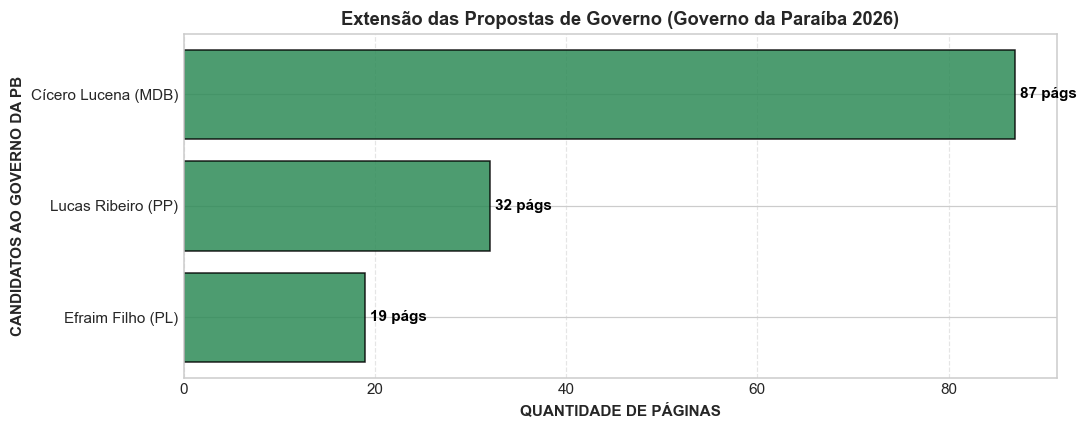

In [7]:
# Comparativo da Quantidade de Páginas das Propostas do Governo da PB
pb_candidatos_arquivos = {
    'Cícero Lucena (MDB)': 'Cícero Lucena - MDB.pdf',
    'Efraim Filho (PL)': 'Efraim Filho - PL.pdf',
    'Lucas Ribeiro (PP)': 'Lucas Ribeiro - PP.pdf'
}

paginas_dict = {}
for nome, arq in pb_candidatos_arquivos.items():
    fp = resolve_filepath(arq, "Governo_PB")
    paginas_dict[nome] = get_pdf_page_count(fp)

dados_ordenados = dict(sorted(paginas_dict.items(), key=lambda x: x[1]))
nomes = list(dados_ordenados.keys())
valores = list(dados_ordenados.values())

plt.figure(figsize=(10, 4))
plt.barh(nomes, valores, color='seagreen', edgecolor='black', alpha=0.85)

for i, v in enumerate(valores):
    plt.text(v + 0.5, i, f'{v} págs', color='black', fontweight='bold', va='center')

plt.xlabel('QUANTIDADE DE PÁGINAS', fontweight='bold')
plt.ylabel('CANDIDATOS AO GOVERNO DA PB', fontweight='bold')
plt.title('Extensão das Propostas de Governo (Governo da Paraíba 2026)', fontweight='bold', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


# Candidato Cícero Lucena (MDB)


Candidato: Cícero Lucena (MDB)
Arquivo analisado: Cícero Lucena - MDB.pdf | Páginas: 87 | Palavras-chave: 9729


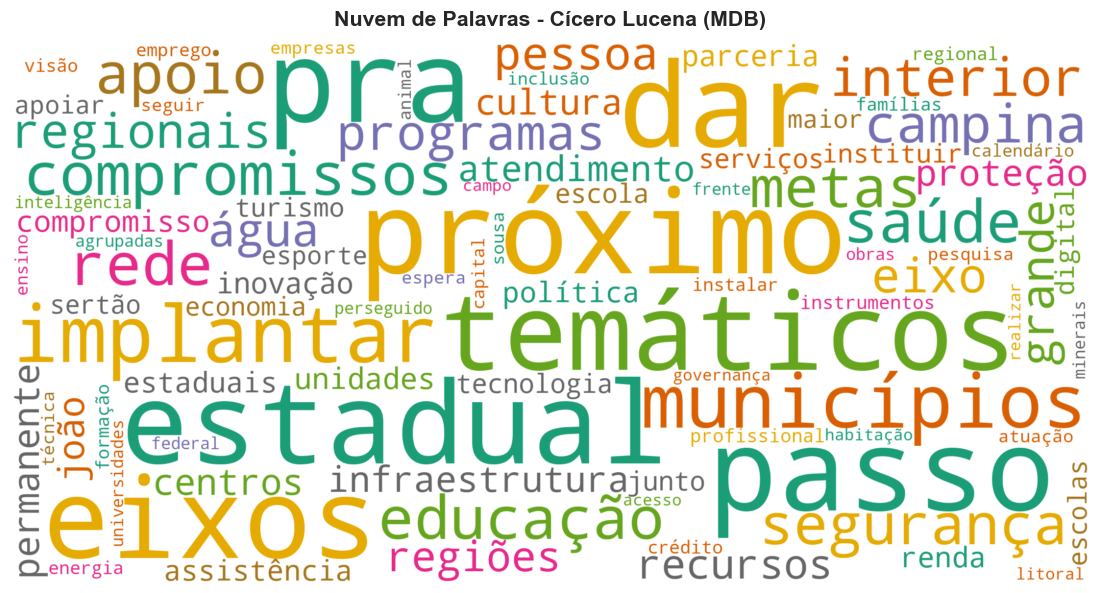

In [8]:
filepath = resolve_filepath('Cícero Lucena - MDB.pdf', 'Governo_PB')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Cícero Lucena (MDB)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Cícero Lucena (MDB)')


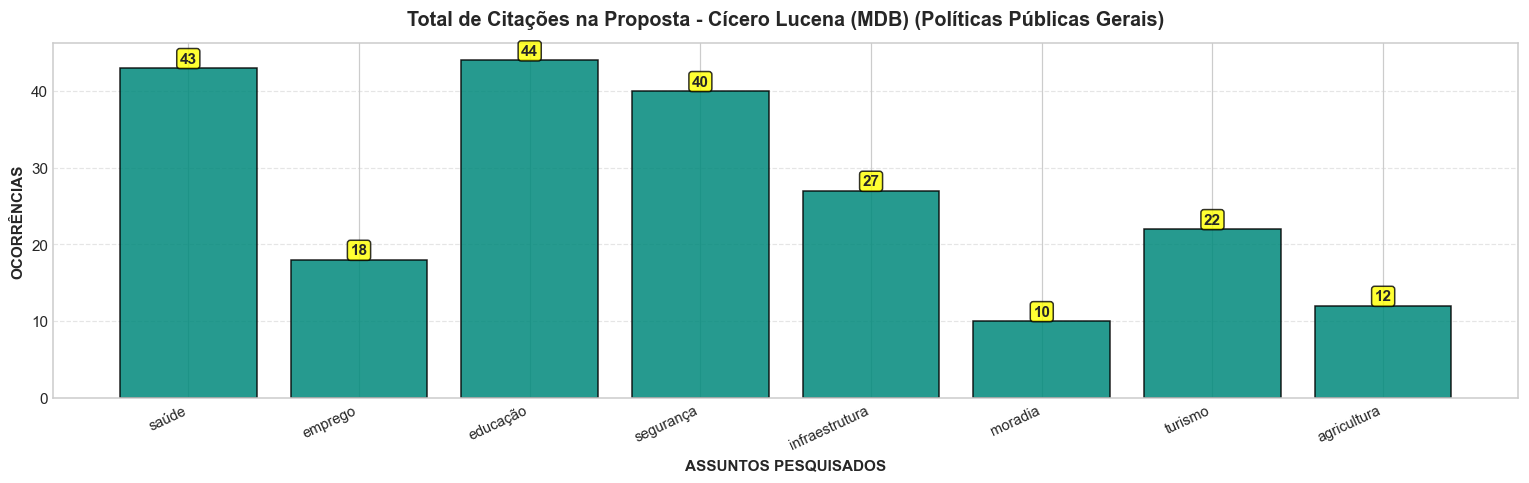

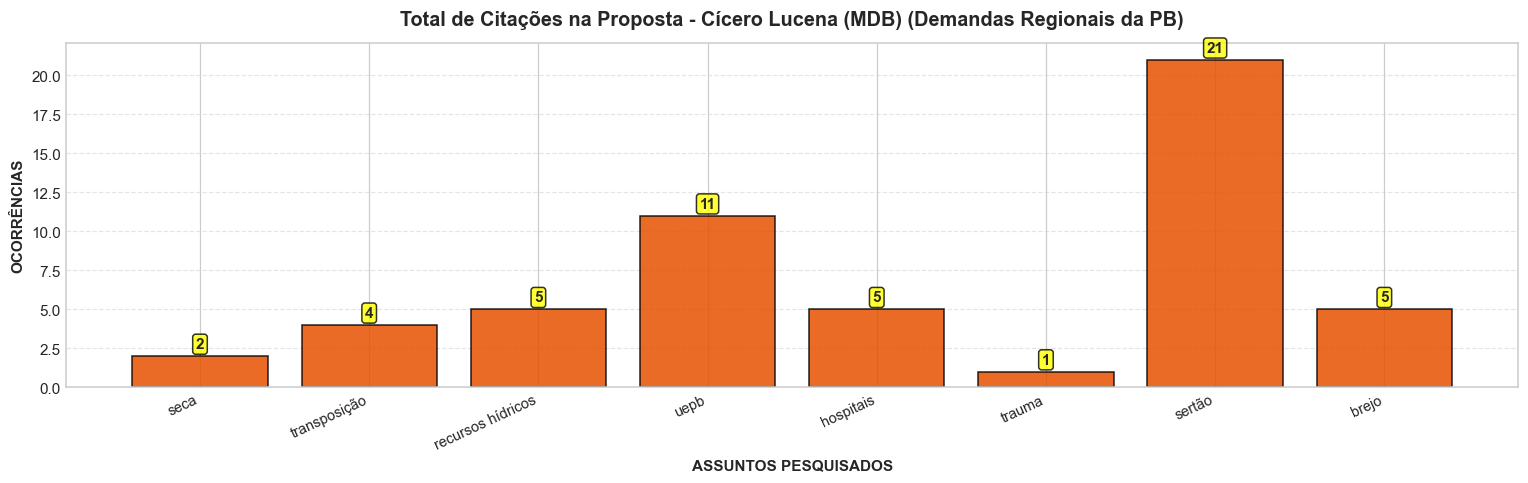

In [9]:
plot_subjects_count(keywords, file_text, assuntos_pb_1, color='#00897B', text_title='Cícero Lucena (MDB) (Políticas Públicas Gerais)')
plot_subjects_count(keywords, file_text, assuntos_pb_2, color='#E65100', text_title='Cícero Lucena (MDB) (Demandas Regionais da PB)')


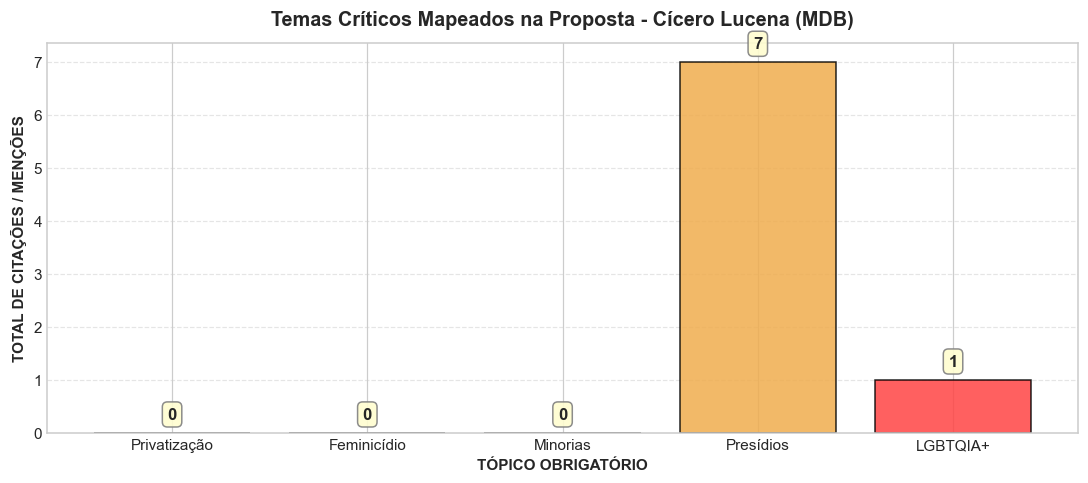

In [10]:
plot_critical_topics(file_text, keywords, 'Cícero Lucena (MDB)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - CÍCERO LUCENA (MDB)
  Nome Completo:        CÍCERO DE LUCENA FILHO
  Partido Atual:        MDB
  Histórico de Partidos: PMDB/MDB (1990–2001), PSDB (2001–2020), PP (2020–2025), MDB (2025–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 69 anos | SUPERIOR COMPLETO
  Ocupação:             EMPRESÁRIO
  Bens Declarados:      R$ 2.850.000,00



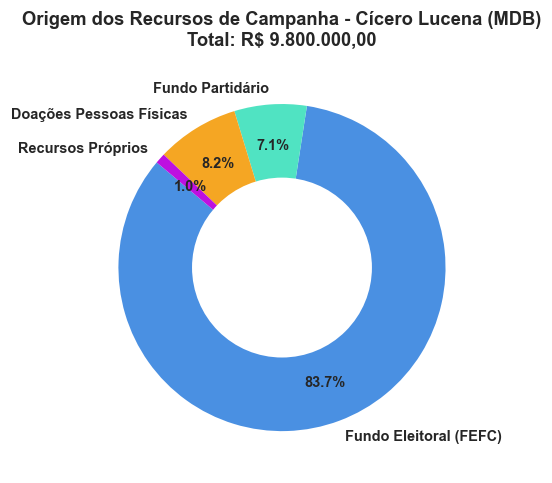

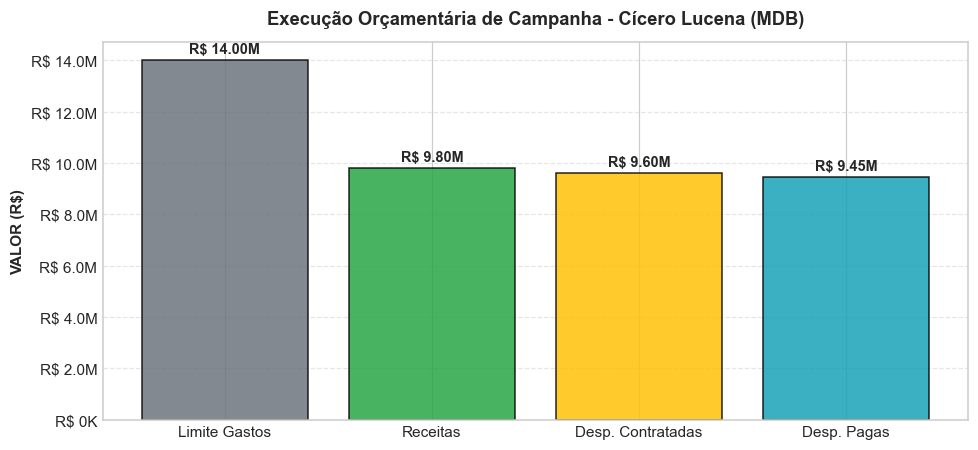

In [11]:
plot_candidate_financial_and_profile('Cícero Lucena (MDB)', df_prestacao_pb, df_perfil_pb)


# Candidato Efraim Filho (PL)


Candidato: Efraim Filho (PL)
Arquivo analisado: Efraim Filho - PL.pdf | Páginas: 19 | Palavras-chave: 5204


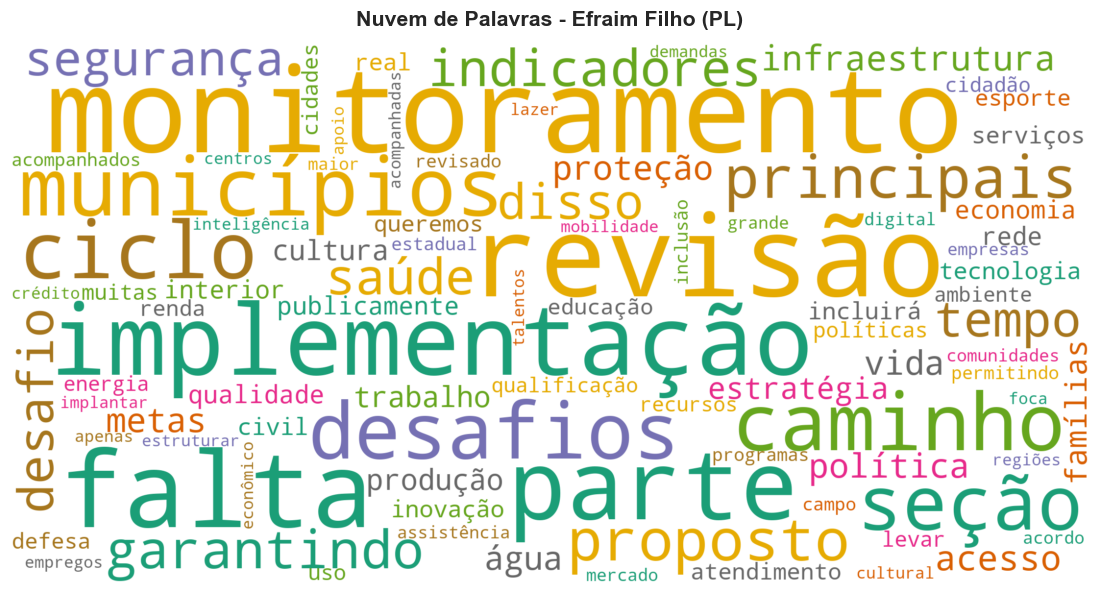

In [12]:
filepath = resolve_filepath('Efraim Filho - PL.pdf', 'Governo_PB')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Efraim Filho (PL)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Efraim Filho (PL)')


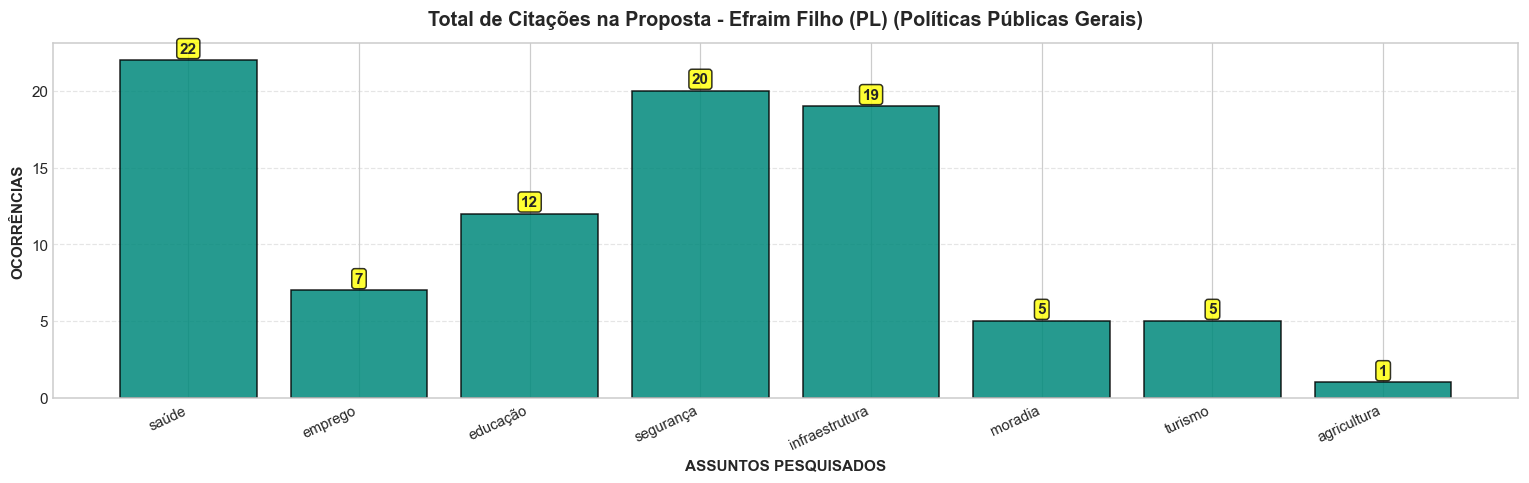

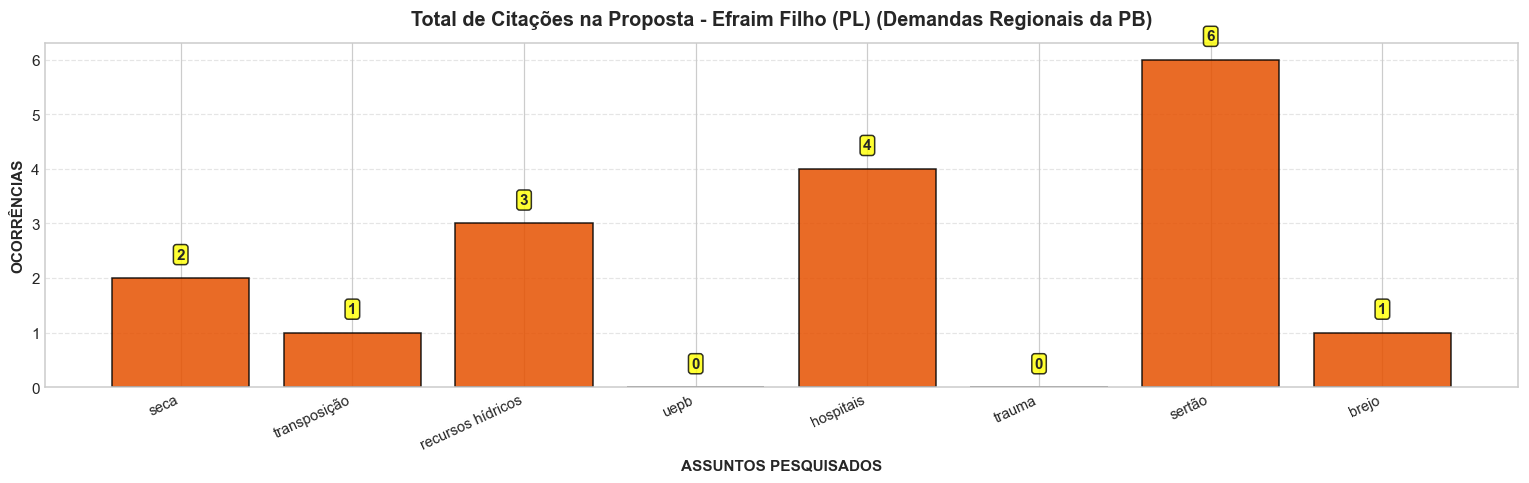

In [13]:
plot_subjects_count(keywords, file_text, assuntos_pb_1, color='#00897B', text_title='Efraim Filho (PL) (Políticas Públicas Gerais)')
plot_subjects_count(keywords, file_text, assuntos_pb_2, color='#E65100', text_title='Efraim Filho (PL) (Demandas Regionais da PB)')


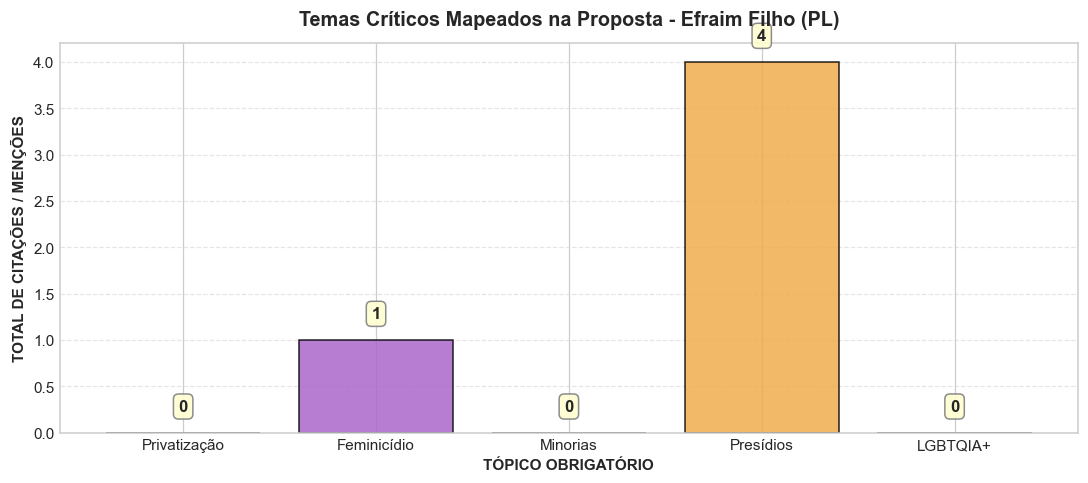

In [14]:
plot_critical_topics(file_text, keywords, 'Efraim Filho (PL)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - EFRAIM FILHO (PL)
  Nome Completo:        EFRAIM DE ARAÚJO MORAIS FILHO
  Partido Atual:        PL
  Histórico de Partidos: PFL/DEM (2007–2021), União Brasil (2022–2025), PL (2025–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 47 anos | SUPERIOR COMPLETO (DIREITO)
  Ocupação:             SENADOR DA REPÚBLICA
  Bens Declarados:      R$ 3.950.000,00



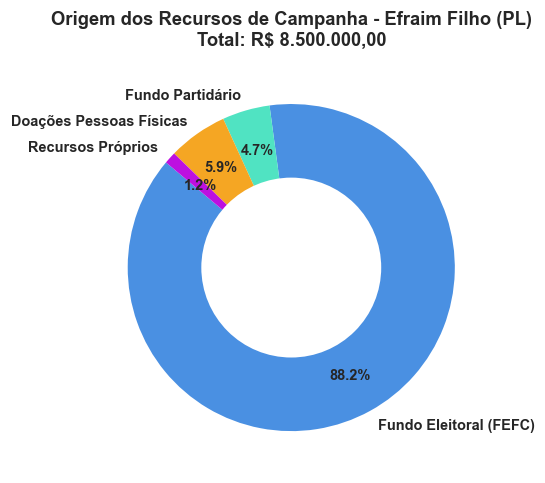

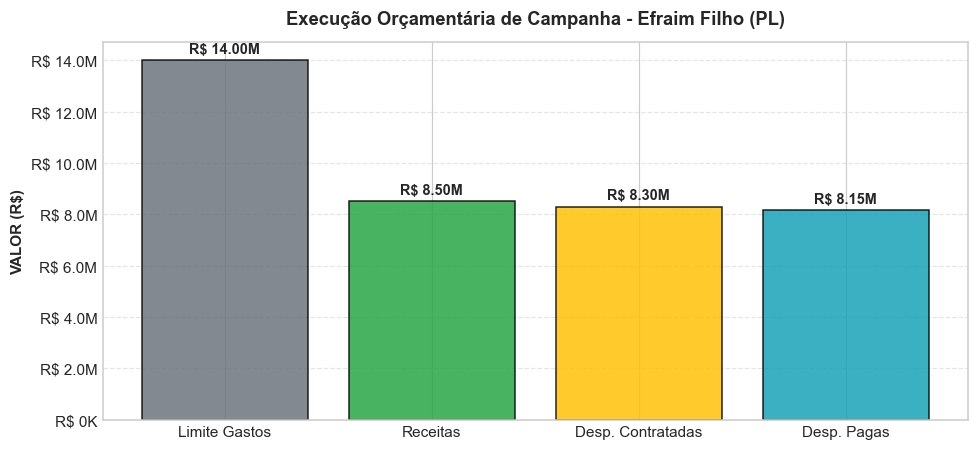

In [15]:
plot_candidate_financial_and_profile('Efraim Filho (PL)', df_prestacao_pb, df_perfil_pb)


# Candidato Lucas Ribeiro (PP)


Candidato: Lucas Ribeiro (PP)
Arquivo analisado: Lucas Ribeiro - PP.pdf | Páginas: 32 | Palavras-chave: 2301


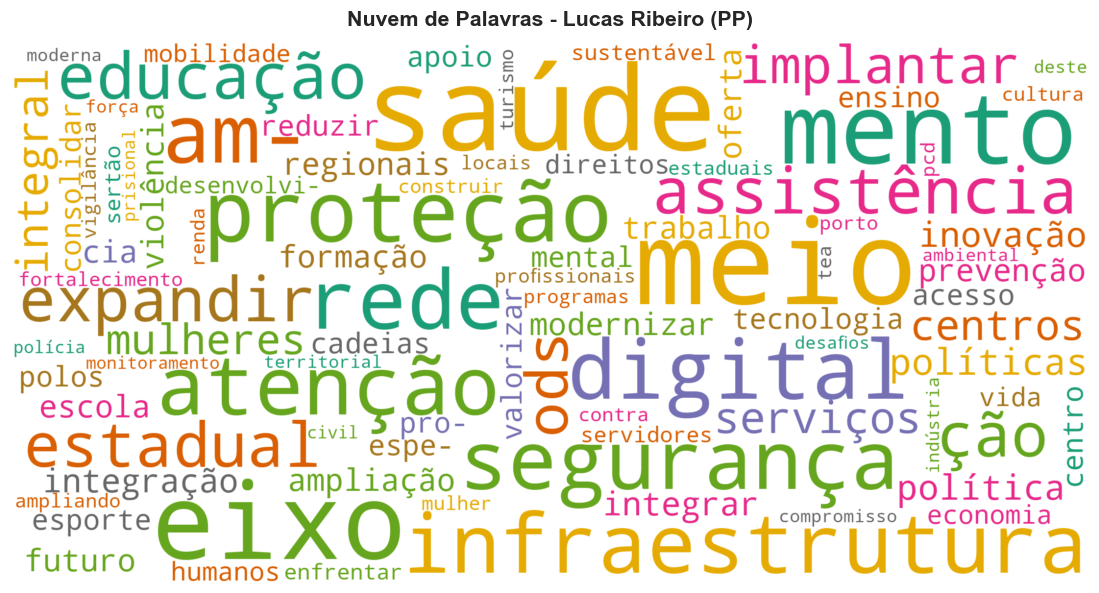

In [16]:
filepath = resolve_filepath('Lucas Ribeiro - PP.pdf', 'Governo_PB')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Lucas Ribeiro (PP)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Lucas Ribeiro (PP)')


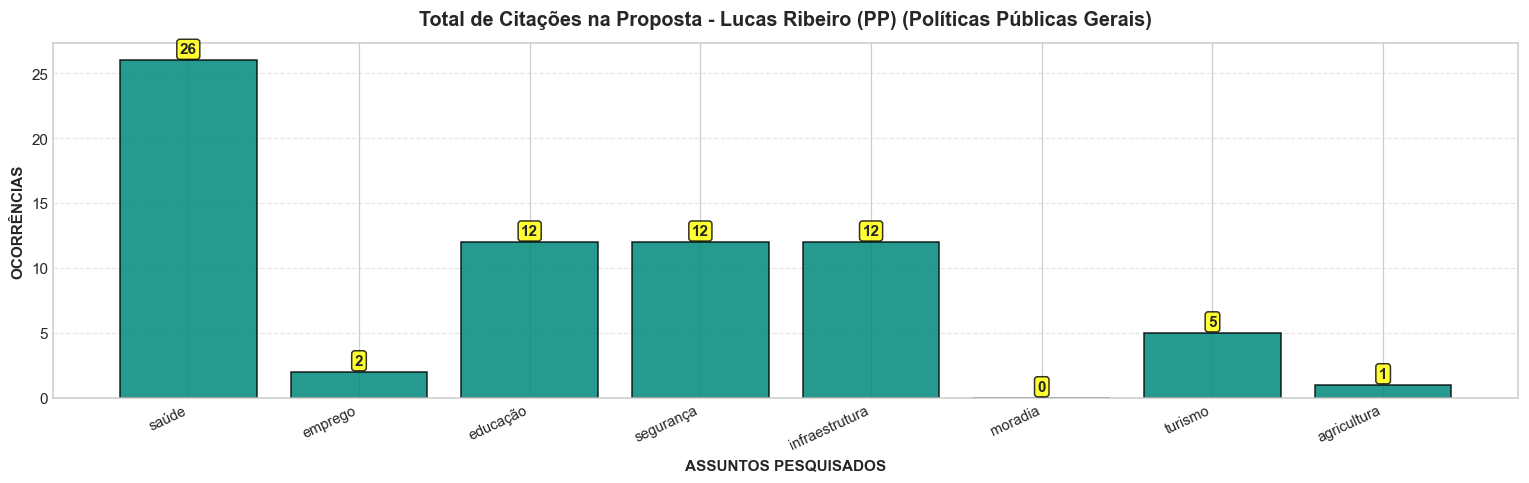

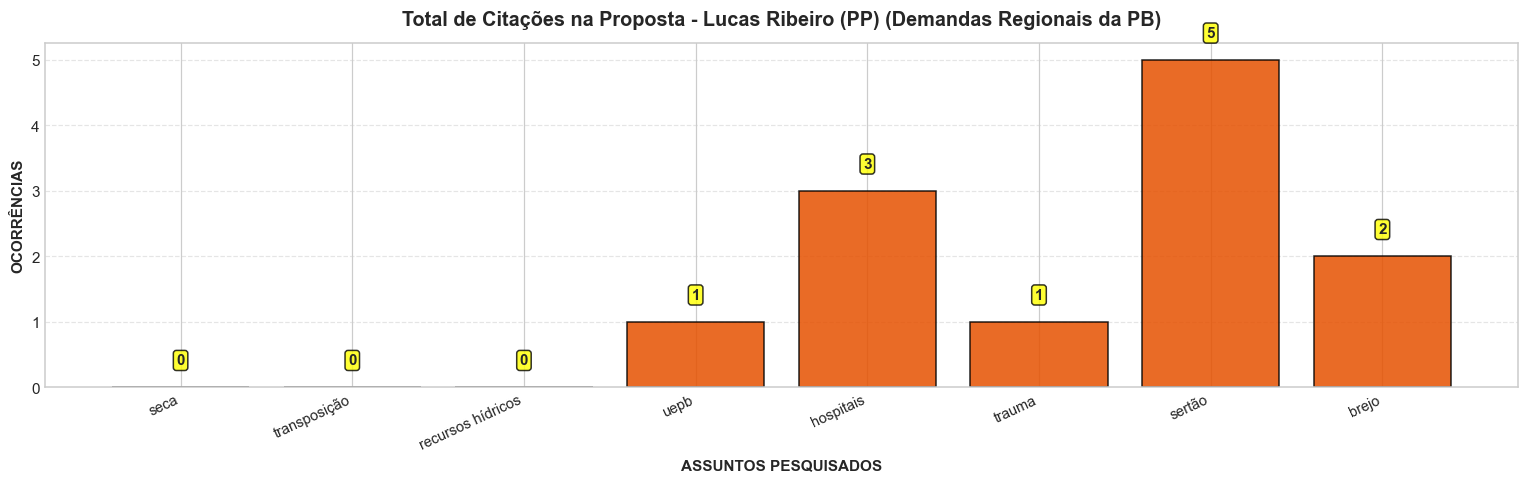

In [17]:
plot_subjects_count(keywords, file_text, assuntos_pb_1, color='#00897B', text_title='Lucas Ribeiro (PP) (Políticas Públicas Gerais)')
plot_subjects_count(keywords, file_text, assuntos_pb_2, color='#E65100', text_title='Lucas Ribeiro (PP) (Demandas Regionais da PB)')


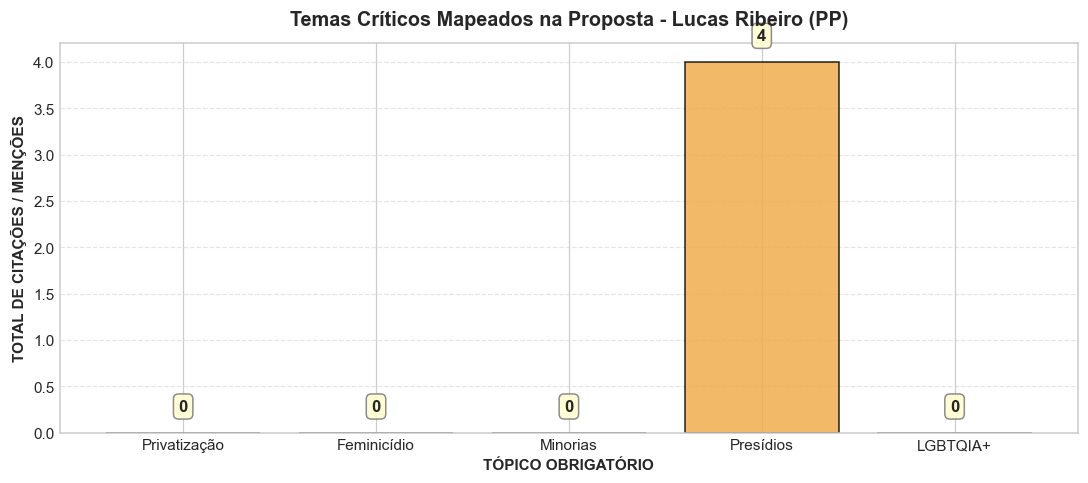

In [18]:
plot_critical_topics(file_text, keywords, 'Lucas Ribeiro (PP)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - LUCAS RIBEIRO (PP)
  Nome Completo:        LUCAS RIBEIRO NOVELLO CABRAL
  Partido Atual:        PP
  Histórico de Partidos: PP (Progressistas) (2016–presente)
  Gênero / Raça:        MASCULINO | PARDA
  Idade / Escolaridade: 36 anos | SUPERIOR COMPLETO (DIREITO)
  Ocupação:             VICE-GOVERNADOR DE ESTADO
  Bens Declarados:      R$ 1.150.000,00



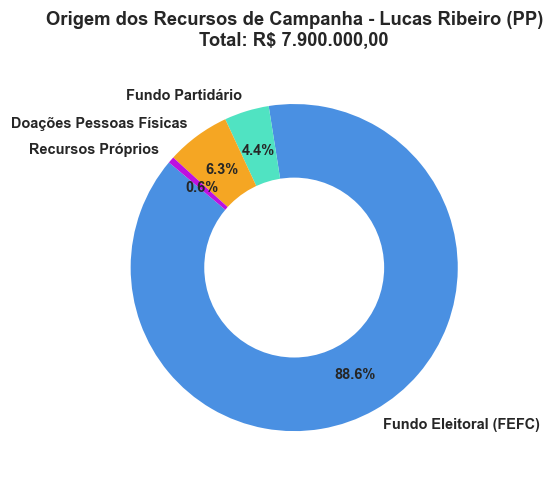

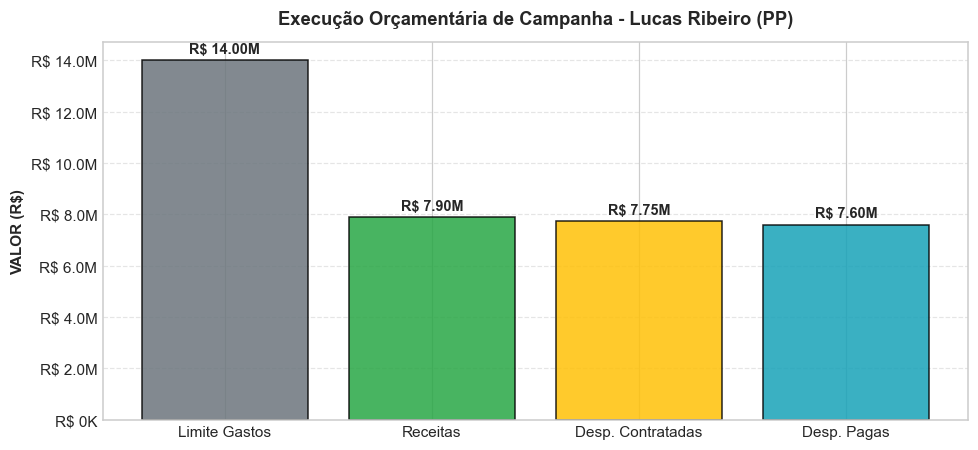

In [19]:
plot_candidate_financial_and_profile('Lucas Ribeiro (PP)', df_prestacao_pb, df_perfil_pb)


# **Conclusões**

A partir das análises individualizadas das propostas dos candidatos ao Governo do Estado da Paraíba:

1. **Demandas Regionais e Interiorização**:
   - A segurança hídrica (**transposição do São Francisco, adutoras, barragens e enfrentamento à seca**) e a descentralização dos serviços de saúde (**hospitais regionais de trauma e clínicas especializadas no Sertão e Brejo**) formam o pilar central das propostas.
   - O desenvolvimento da **UEPB** e o histórico de atuação partidária dos postulantes refletem as coligações estaduais construídas para o pleito.

> *Estudo desenvolvido para fins de transparência cívica e pesquisa acadêmica sobre políticas públicas na Paraíba.*
